# Level 2 — Task 2: Decision Trees for Classification
**Intern:** Amos Njama Mungai | **Company:** Codveda Technologies

**Dataset:** Iris Dataset (1) iris.csv)

**Objectives:**
- Train a decision tree on a labeled dataset
- Visualize the tree structure
- Prune the tree to prevent overfitting
- Evaluate using accuracy and F1-score

**Tools:** Python, Scikit-learn, Pandas, Matplotlib

## Step 1: Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted successfully')

Mounted at /content/drive
✅ Google Drive mounted successfully


## Step 2: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, precision_score, recall_score
)

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


## Step 3: Load the Dataset

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Data Set For Task/1) iris.csv')
print('✅ Dataset loaded successfully')
print(f'Shape: {df.shape}')
df.head(10)

✅ Dataset loaded successfully
Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


## Step 4: Explore & Preprocess

In [4]:
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Class Distribution ===')
print(df['species'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

=== Missing Values ===
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

=== Class Distribution ===
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [5]:
# Encode target
le = LabelEncoder()
df['species_encoded'] = le.fit_transform(df['species'])
print('Label Encoding:')
print(df[['species', 'species_encoded']].drop_duplicates())

# Features and target
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X = df[features]
y = df['species_encoded']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTraining samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')

Label Encoding:
        species  species_encoded
0        setosa                0
50   versicolor                1
100   virginica                2

Training samples : 120
Testing samples  : 30


## Step 5: Train Full Decision Tree (No Pruning)

In [6]:
# Unpruned tree
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train, y_train)
y_pred_full = dt_full.predict(X_test)

print('=== Full Tree (No Pruning) ===')
print(f'Tree Depth        : {dt_full.get_depth()}')
print(f'Number of Leaves  : {dt_full.get_n_leaves()}')
print(f'Accuracy          : {accuracy_score(y_test, y_pred_full)*100:.2f}%')
print(f'F1-Score          : {f1_score(y_test, y_pred_full, average="weighted")*100:.2f}%')

=== Full Tree (No Pruning) ===
Tree Depth        : 5
Number of Leaves  : 8
Accuracy          : 93.33%
F1-Score          : 93.33%


## Step 6: Visualize Full Tree Structure

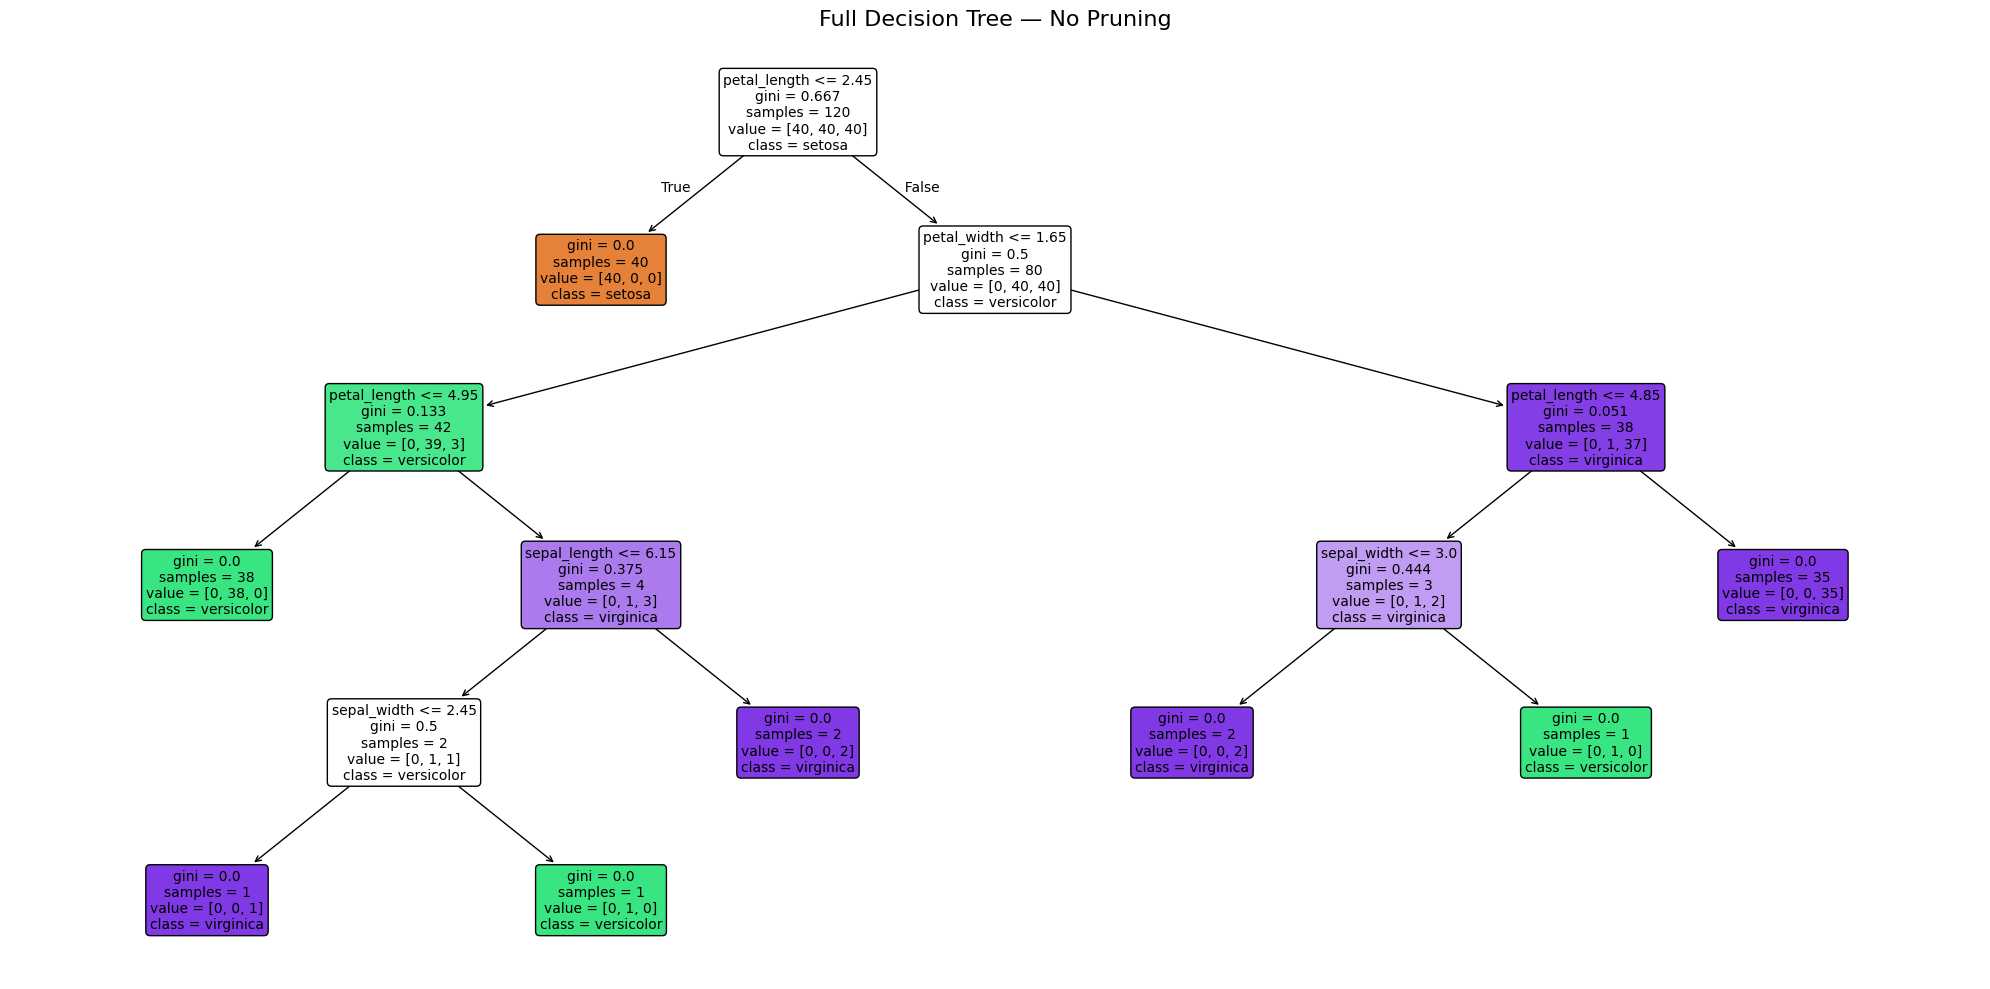

In [7]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_full,
    feature_names=features,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Full Decision Tree — No Pruning', fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
# Text representation of tree
print('=== Tree Rules ===')
print(export_text(dt_full, feature_names=features))

=== Tree Rules ===
|--- petal_length <= 2.45
|   |--- class: 0
|--- petal_length >  2.45
|   |--- petal_width <= 1.65
|   |   |--- petal_length <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal_length >  4.95
|   |   |   |--- sepal_length <= 6.15
|   |   |   |   |--- sepal_width <= 2.45
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- sepal_width >  2.45
|   |   |   |   |   |--- class: 1
|   |   |   |--- sepal_length >  6.15
|   |   |   |   |--- class: 2
|   |--- petal_width >  1.65
|   |   |--- petal_length <= 4.85
|   |   |   |--- sepal_width <= 3.00
|   |   |   |   |--- class: 2
|   |   |   |--- sepal_width >  3.00
|   |   |   |   |--- class: 1
|   |   |--- petal_length >  4.85
|   |   |   |--- class: 2



## Step 7: Prune the Tree to Prevent Overfitting

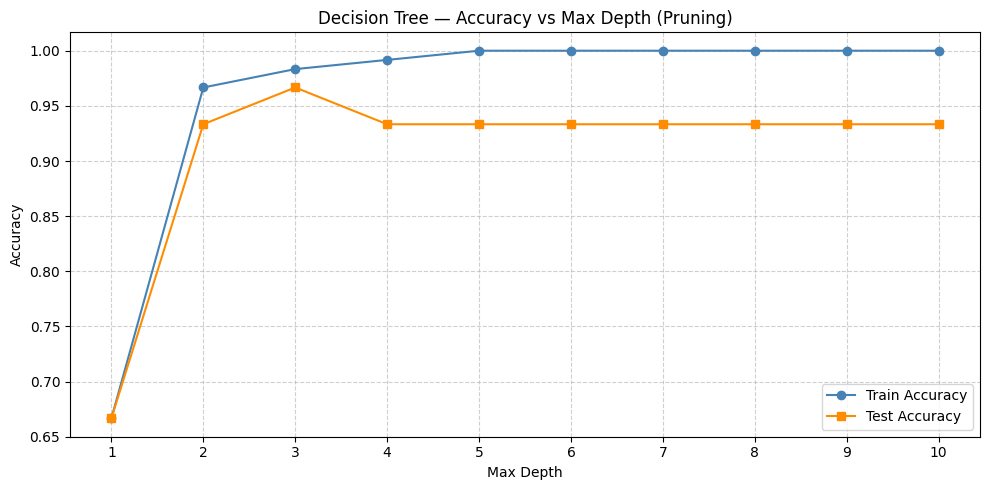


✅ Best max_depth = 3 with Test Accuracy = 96.67%


In [9]:
# Try different max_depth values to find best pruning
depths = range(1, 11)
train_scores = []
test_scores  = []

for depth in depths:
    dt_temp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_temp.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, dt_temp.predict(X_train)))
    test_scores.append(accuracy_score(y_test, dt_temp.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, marker='o', label='Train Accuracy', color='steelblue')
plt.plot(depths, test_scores,  marker='s', label='Test Accuracy',  color='darkorange')
plt.title('Decision Tree — Accuracy vs Max Depth (Pruning)')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.xticks(depths)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

best_depth = depths[test_scores.index(max(test_scores))]
print(f'\n✅ Best max_depth = {best_depth} with Test Accuracy = {max(test_scores)*100:.2f}%')

In [10]:
# Train pruned tree with best depth
dt_pruned = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_pruned.fit(X_train, y_train)
y_pred_pruned = dt_pruned.predict(X_test)

print('=== Pruned Tree ===')
print(f'Max Depth        : {best_depth}')
print(f'Tree Depth       : {dt_pruned.get_depth()}')
print(f'Number of Leaves : {dt_pruned.get_n_leaves()}')
print(f'Accuracy         : {accuracy_score(y_test, y_pred_pruned)*100:.2f}%')
print(f'F1-Score         : {f1_score(y_test, y_pred_pruned, average="weighted")*100:.2f}%')

=== Pruned Tree ===
Max Depth        : 3
Tree Depth       : 3
Number of Leaves : 5
Accuracy         : 96.67%
F1-Score         : 96.66%


## Step 8: Visualize Pruned Tree

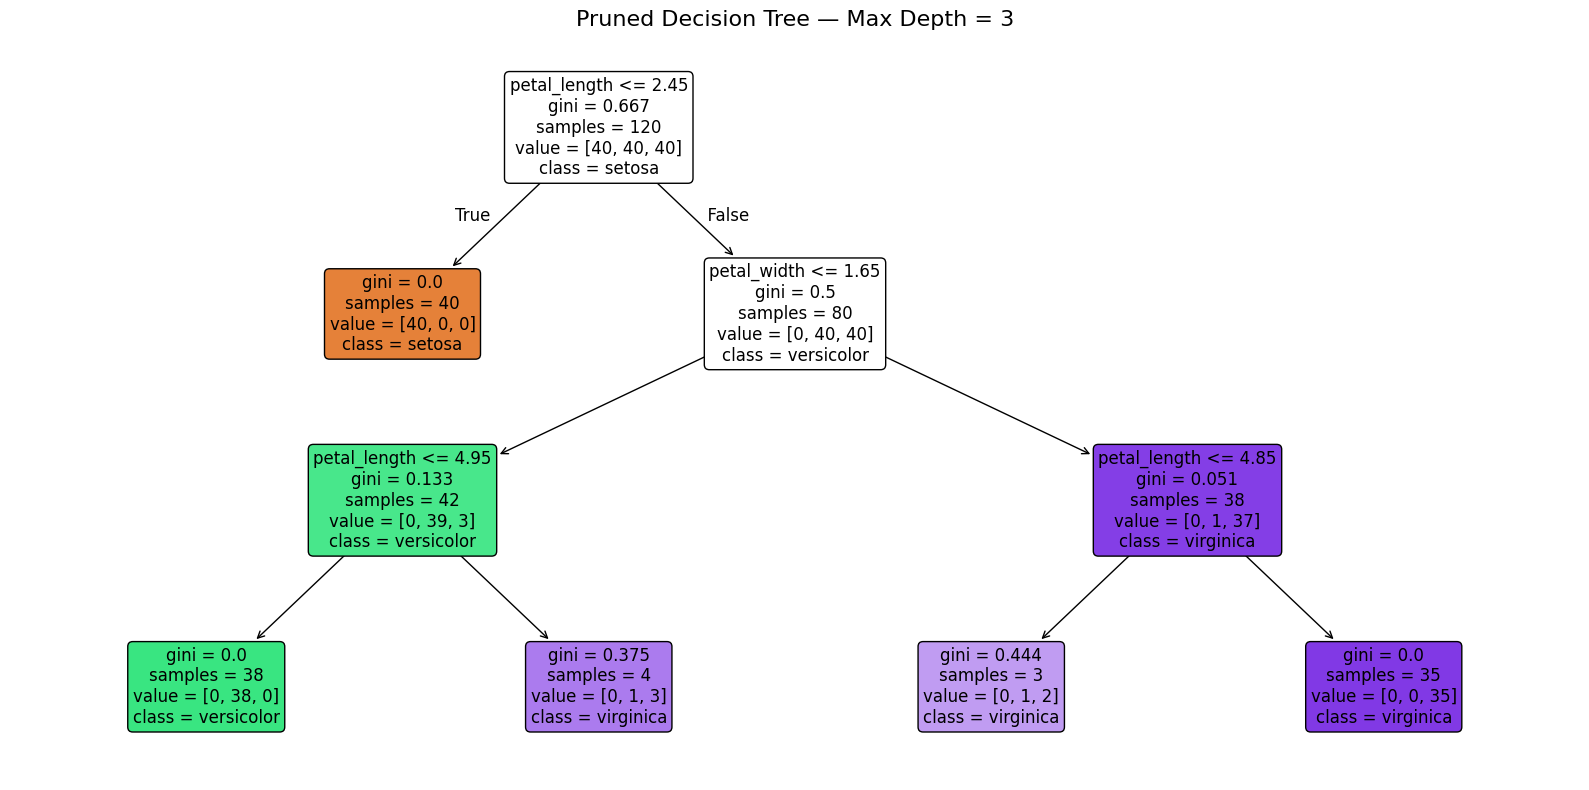

In [11]:
plt.figure(figsize=(16, 8))
plot_tree(
    dt_pruned,
    feature_names=features,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title(f'Pruned Decision Tree — Max Depth = {best_depth}', fontsize=16)
plt.tight_layout()
plt.show()

## Step 9: Evaluate the Pruned Model

In [12]:
accuracy  = accuracy_score(y_test, y_pred_pruned)
f1        = f1_score(y_test, y_pred_pruned, average='weighted')
precision = precision_score(y_test, y_pred_pruned, average='weighted')
recall    = recall_score(y_test, y_pred_pruned, average='weighted')

print('============================================')
print(f'   MODEL EVALUATION  (Pruned, Depth={best_depth})')
print('============================================')
print(f'  Accuracy  : {accuracy*100:.2f}%')
print(f'  Precision : {precision*100:.2f}%')
print(f'  Recall    : {recall*100:.2f}%')
print(f'  F1-Score  : {f1*100:.2f}%')
print('============================================')
print()
print('=== Full Classification Report ===')
print(classification_report(y_test, y_pred_pruned, target_names=le.classes_))

   MODEL EVALUATION  (Pruned, Depth=3)
  Accuracy  : 96.67%
  Precision : 96.97%
  Recall    : 96.67%
  F1-Score  : 96.66%

=== Full Classification Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



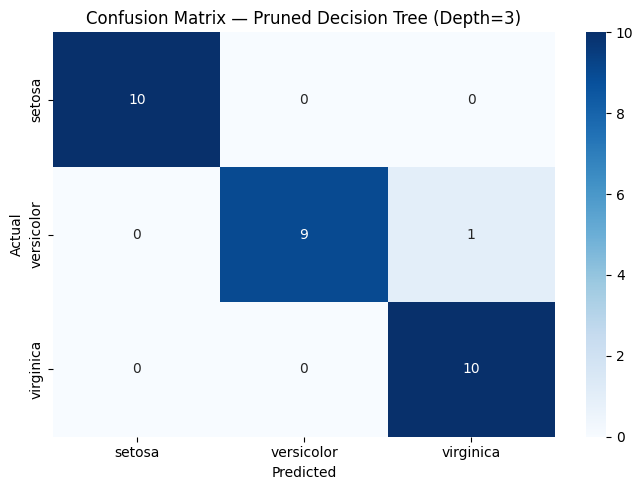

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_pruned)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix — Pruned Decision Tree (Depth={best_depth})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Step 10: Feature Importance

=== Feature Importance ===
     Feature  Importance
petal_length    0.579077
 petal_width    0.420923
 sepal_width    0.000000
sepal_length    0.000000


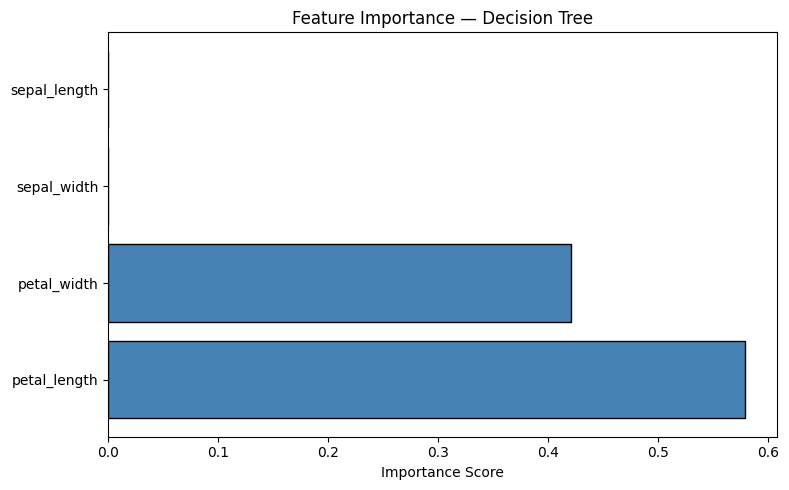

In [14]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': dt_pruned.feature_importances_
}).sort_values('Importance', ascending=False)

print('=== Feature Importance ===')
print(importance_df.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'],
         color='steelblue', edgecolor='black')
plt.title('Feature Importance — Decision Tree')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Step 11: Full vs Pruned Tree Comparison

In [15]:
print('=== Full Tree vs Pruned Tree ===')
print(f"{'Metric':<20} {'Full Tree':>12} {'Pruned Tree':>12}")
print('-' * 46)
print(f"{'Depth':<20} {dt_full.get_depth():>12} {dt_pruned.get_depth():>12}")
print(f"{'Leaves':<20} {dt_full.get_n_leaves():>12} {dt_pruned.get_n_leaves():>12}")
print(f"{'Accuracy':<20} {accuracy_score(y_test, y_pred_full)*100:>11.2f}% {accuracy_score(y_test, y_pred_pruned)*100:>11.2f}%")
print(f"{'F1-Score':<20} {f1_score(y_test, y_pred_full, average='weighted')*100:>11.2f}% {f1_score(y_test, y_pred_pruned, average='weighted')*100:>11.2f}%")
print('\n📌 Pruning reduces complexity while maintaining accuracy!')

=== Full Tree vs Pruned Tree ===
Metric                  Full Tree  Pruned Tree
----------------------------------------------
Depth                           5            3
Leaves                          8            5
Accuracy                   93.33%       96.67%
F1-Score                   93.33%       96.66%

📌 Pruning reduces complexity while maintaining accuracy!
